# Laboratorio 5 - Modelación de Clasificación

Este notebook desarrolla un pipeline completo de Machine Learning para un problema de clasificación, incluyendo exploración inicial, preparación de datos, entrenamiento de modelos, validación cruzada, ajuste de hiperparámetros, evaluación final e interpretación de resultados.

In [39]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path

pd.set_option("display.max_columns", None)

In [40]:
ruta_db = Path("../database/clasificacion.db")

ruta_db.exists()

True

In [41]:
conn = sqlite3.connect(ruta_db)

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tablas

,name
0,clasificacion


In [42]:
df = pd.read_sql_query("SELECT * FROM clasificacion;", conn)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [43]:
df.shape


(400, 25)

In [44]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='str')

In [45]:
df["class"].value_counts()

class
ckd       250
notckd    150
Name: count, dtype: int64

In [46]:
df["class"].value_counts(normalize=True) * 100

class
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64

## 1. Comprensión del problema

El problema corresponde a una tarea de clasificación binaria, donde se busca predecir si un paciente presenta o no enfermedad renal crónica.

La variable objetivo es `class`, la cual contiene dos clases:

- `ckd`: paciente con enfermedad renal crónica.
- `notckd`: paciente sin enfermedad renal crónica.

La base de datos contiene 400 registros y 25 columnas. De estos registros, 250 pertenecen a la clase `ckd` y 150 a la clase `notckd`.

Esto indica que la clase `ckd` representa aproximadamente el 62.5% de los datos, mientras que la clase `notckd` representa aproximadamente el 37.5%. Por tanto, existe un desbalance moderado entre las clases, aunque no es un desbalance extremo.

En este contexto, no basta con evaluar los modelos únicamente mediante Accuracy, ya que será importante revisar también métricas como Precision, Recall, F1-Score y AUC para analizar mejor el comportamiento del modelo en ambas clases.

## 2. Exploración inicial de los datos

En esta sección se revisan las características generales de la base de datos, incluyendo el tipo de variables, la presencia de valores faltantes y la separación entre variables numéricas y categóricas.

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

In [48]:
valores_faltantes = df.isnull().sum().sort_values(ascending=False)

valores_faltantes

rbc      152
rbcc     131
wbcc     106
pot       88
sod       87
pcv       71
pc        65
hemo      52
su        49
sg        47
al        46
bgr       44
bu        19
sc        17
bp        12
age        9
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

In [49]:
porcentaje_faltantes = (df.isnull().mean() * 100).sort_values(ascending=False)

porcentaje_faltantes

rbc      38.00
rbcc     32.75
wbcc     26.50
pot      22.00
sod      21.75
pcv      17.75
pc       16.25
hemo     13.00
su       12.25
sg       11.75
al       11.50
bgr      11.00
bu        4.75
sc        4.25
bp        3.00
age       2.25
pcc       1.00
ba        1.00
htn       0.50
dm        0.50
cad       0.50
appet     0.25
pe        0.25
ane       0.25
class     0.00
dtype: float64

### Análisis de tipos de variables y valores faltantes

La base de datos contiene 400 registros y 25 columnas. De estas columnas, 14 corresponden a variables numéricas y 11 a variables categóricas o de texto.

La variable objetivo es `class`, la cual no presenta valores faltantes. Esto es importante porque permite utilizar todos los registros para la construcción del modelo de clasificación.

Sin embargo, varias variables predictoras presentan valores faltantes. Las variables con mayor cantidad de datos ausentes son `rbc`, `rbcc`, `wbcc`, `pot`, `sod`, `pcv`, `pc` y `hemo`. Por esta razón, no es recomendable eliminar directamente las filas incompletas, ya que se perdería una parte importante de la información disponible.

Para manejar este problema, en la etapa de preparación de los datos se aplicará imputación de valores faltantes dentro de un `Pipeline`. Esto permite evitar fuga de información, ya que las transformaciones se ajustan únicamente con los datos de entrenamiento.

In [50]:
# Separar variable objetivo y variables predictoras
target = "class"

X = df.drop(columns=[target])
y = df[target]

# Identificar variables numéricas y categóricas solo en X
columnas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Variable objetivo:")
print(target)

print("\nVariables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

print("\nCantidad de variables numéricas:", len(columnas_numericas))
print("Cantidad de variables categóricas:", len(columnas_categoricas))

Variable objetivo:
class

Variables numéricas:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

Variables categóricas:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Cantidad de variables numéricas: 14
Cantidad de variables categóricas: 10


In [51]:
# Distribución de la variable objetivo
conteo_clases = y.value_counts()
porcentaje_clases = y.value_counts(normalize=True) * 100

display(conteo_clases)
display(porcentaje_clases)

class
ckd       250
notckd    150
Name: count, dtype: int64

class
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64

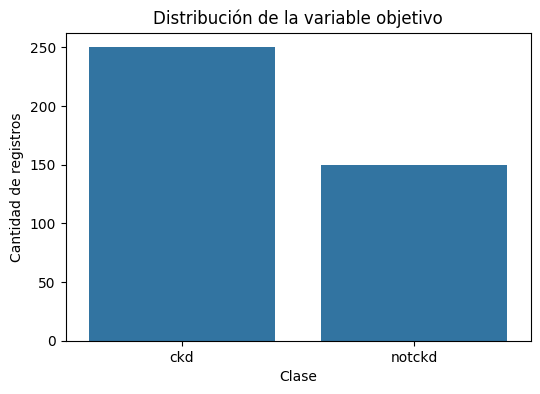

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.show()

### Distribución de clases

La variable objetivo `class` presenta dos categorías: `ckd` y `notckd`.

La clase `ckd` tiene 250 registros, mientras que la clase `notckd` tiene 150 registros. En términos porcentuales, `ckd` representa aproximadamente el 62.5% de los datos y `notckd` representa aproximadamente el 37.5%.

Esto muestra un desbalance moderado entre las clases. No es un desbalance extremo, pero sí debe tenerse en cuenta al evaluar los modelos. Por esta razón, no se utilizará únicamente Accuracy como criterio de selección, sino también métricas como Precision, Recall, F1-Score y AUC.


In [53]:
# Resumen estadístico de variables numéricas
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


### Análisis de variables numéricas

Las variables numéricas presentan diferentes escalas de medición. Por ejemplo, variables como `sg`, `al` y `su` tienen rangos pequeños, mientras que variables como `bgr`, `bu`, `wbcc` y `rbcc` presentan valores en escalas más amplias.

También se observan posibles valores extremos en algunas variables, como `bp`, `bgr`, `bu`, `sc`, `sod`, `pot` y `wbcc`. Estos valores no se eliminarán directamente en esta etapa, ya que pueden corresponder a condiciones clínicas reales o a registros atípicos que deben ser tratados con cuidado.

Además, varias variables numéricas tienen valores faltantes, por lo que en la preparación de los datos será necesario aplicar imputación. Esta imputación se realizará dentro de un `Pipeline`, con el fin de evitar fuga de información entre los datos de entrenamiento y prueba.


In [54]:
# Resumen ordenado de variables categóricas
resumen_categoricas = []

for col in columnas_categoricas:
    conteos = df[col].value_counts(dropna=False)
    
    for categoria, conteo in conteos.items():
        resumen_categoricas.append({
            "variable": col,
            "categoria": categoria,
            "conteo": conteo,
            "porcentaje": round((conteo / len(df)) * 100, 2)
        })

resumen_categoricas = pd.DataFrame(resumen_categoricas)

resumen_categoricas

,variable,categoria,conteo,porcentaje
0,rbc,normal,201,50.25
1,rbc,NaN,152,38.00
2,rbc,abnormal,47,11.75
3,pc,normal,259,64.75
4,pc,abnormal,76,19.00
5,pc,NaN,65,16.25
6,pcc,notpresent,354,88.50
7,pcc,present,42,10.50
8,pcc,NaN,4,1.00
9,ba,notpresent,374,93.50


### Análisis de variables categóricas

Las variables categóricas presentan principalmente categorías binarias, como `yes`/`no`, `present`/`notpresent`, `normal`/`abnormal` y `good`/`poor`.

Se observa que las variables `rbc` y `pc` presentan una mayor cantidad de valores faltantes. En particular, `rbc` tiene 152 valores faltantes, equivalentes al 38% de la base, mientras que `pc` tiene 65 valores faltantes, equivalentes al 16.25%.

Las demás variables categóricas presentan pocos valores faltantes. Por esta razón, estas variables no serán eliminadas, sino que serán tratadas mediante imputación dentro del `Pipeline`.

Posteriormente, las variables categóricas serán codificadas mediante `OneHotEncoder`, permitiendo que los modelos de clasificación puedan utilizarlas correctamente.


## 3. Preparación de los datos

En esta sección se realiza la separación entre variables predictoras y variable objetivo. Posteriormente, se divide la base de datos en conjunto de entrenamiento y conjunto de prueba, utilizando el 70% de los datos para entrenamiento y el 30% para prueba.

La imputación de valores faltantes, la codificación de variables categóricas y el escalamiento se realizarán más adelante dentro de un `Pipeline`, con el fin de evitar fuga de información.

Además, se utilizarán dos esquemas de preprocesamiento:

- Para Regresión Logística: imputación, codificación de variables categóricas y escalamiento de variables numéricas.
- Para modelos basados en árboles: imputación con `KNNImputer` y codificación de variables categóricas. Aunque estos modelos no requieren escalamiento para entrenar, se aplica `StandardScaler` antes de `KNNImputer` porque este método de imputación utiliza distancias.

In [55]:
from sklearn.model_selection import train_test_split

# Variable objetivo
target = "class"

# Separar variables predictoras y variable objetivo
X = df.drop(columns=[target])
y = df[target]

# Codificar la variable objetivo
# ckd = 1, notckd = 0
y = y.map({
    "notckd": 0,
    "ckd": 1
})

# División train/test: 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (280, 24)
Tamaño de X_test: (120, 24)
Tamaño de y_train: (280,)
Tamaño de y_test: (120,)


In [20]:
print("Distribución en entrenamiento:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Distribución en entrenamiento:
class
1    175
0    105
Name: count, dtype: int64
class
1    62.5
0    37.5
Name: proportion, dtype: float64

Distribución en prueba:
class
1    75
0    45
Name: count, dtype: int64
class
1    62.5
0    37.5
Name: proportion, dtype: float64


### División de los datos

La base de datos se dividió en conjunto de entrenamiento y conjunto de prueba, utilizando el 70% de los registros para entrenamiento y el 30% para prueba.

El conjunto de entrenamiento quedó conformado por 280 registros y el conjunto de prueba por 120 registros. La división se realizó de forma estratificada, con el fin de conservar en ambos conjuntos una proporción similar de las clases de la variable objetivo.

La clase `ckd` fue codificada como 1 y la clase `notckd` como 0. Esta codificación permite utilizar la variable objetivo en los modelos de clasificación.


## 4. Preprocesamiento dentro de Pipeline

En esta sección se definen los transformadores que se utilizarán para preparar los datos antes del entrenamiento de los modelos.

El preprocesamiento se realizará dentro de un `Pipeline` para evitar fuga de información. Esto significa que la imputación, la codificación de variables categóricas y el escalamiento se ajustarán únicamente con los datos de entrenamiento.

Se utilizarán dos esquemas de preprocesamiento:

- Para Regresión Logística, se aplicará imputación de valores faltantes, codificación de variables categóricas y escalamiento de variables numéricas mediante `StandardScaler`.
- Para modelos basados en árboles, se aplicará imputación con `KNNImputer` y codificación de variables categóricas. Aunque los árboles no requieren escalamiento para modelar, se utiliza `StandardScaler` antes de `KNNImputer` porque este método de imputación se basa en distancias.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---------------------------------------------------------
# Preprocesamiento para variables numéricas
# ---------------------------------------------------------
# Se usa StandardScaler antes de KNNImputer porque KNN trabaja con distancias.
# Si las variables están en escalas muy diferentes, variables como wbcc podrían dominar la imputación.
# Después de KNNImputer se vuelve a aplicar StandardScaler para dejar las variables listas
# para modelos sensibles a la escala, como Regresión Logística.

numeric_transformer_logistic = Pipeline(steps=[
    ("scaler_before_knn", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler_after_knn", StandardScaler())
])

# Para modelos basados en árboles también se usa escalamiento antes del KNNImputer,
# pero por necesidad del método de imputación, no porque el árbol lo requiera.
# Los árboles no necesitan escalamiento para modelar, pero KNNImputer sí se beneficia
# de que las variables estén en escalas comparables.

numeric_transformer_tree = Pipeline(steps=[
    ("scaler_before_knn", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5))
])

# ---------------------------------------------------------
# Preprocesamiento para variables categóricas
# ---------------------------------------------------------
# Para categóricas se usa la categoría más frecuente.
# Luego se aplica OneHotEncoder para convertir las categorías en variables numéricas.

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ---------------------------------------------------------
# Preprocesador para Regresión Logística
# ---------------------------------------------------------

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logistic, columnas_numericas),
        ("cat", categorical_transformer, columnas_categoricas)
    ]
)

# ---------------------------------------------------------
# Preprocesador para modelos basados en árboles
# ---------------------------------------------------------

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, columnas_numericas),
        ("cat", categorical_transformer, columnas_categoricas)
    ]
)

print("Preprocesador para Regresión Logística con KNNImputer creado correctamente.")
print("Preprocesador para modelos de árboles con KNNImputer creado correctamente.")

Preprocesador para Regresión Logística con KNNImputer creado correctamente.
Preprocesador para modelos de árboles con KNNImputer creado correctamente.


### Método de imputación utilizado

Para las variables numéricas se utilizó `KNNImputer(n_neighbors=5)`. Este método reemplaza los valores faltantes utilizando la información de los registros más similares, de acuerdo con la distancia entre observaciones.

Antes de aplicar `KNNImputer`, se utiliza `StandardScaler` en las variables numéricas, ya que KNN es un método basado en distancias. Si no se escalan las variables, aquellas con valores más grandes, como `wbcc`, podrían dominar el cálculo de similitud.

Para las variables categóricas se utilizó `SimpleImputer(strategy="most_frequent")`, reemplazando los valores faltantes por la categoría más frecuente de cada variable. Posteriormente, estas variables se codifican mediante `OneHotEncoder`.

La imputación se realiza dentro del `Pipeline`, no directamente sobre el dataframe original. Esto evita fuga de información, ya que los valores utilizados para imputar se calculan únicamente con los datos de entrenamiento durante cada proceso de validación o ajuste.

## 5. Modelos de clasificación

En esta sección se definen los modelos de clasificación solicitados en el laboratorio. Cada modelo se construye dentro de un `Pipeline`, de manera que el preprocesamiento y el entrenamiento se realicen de forma integrada.

Se entrenarán los siguientes modelos:

- Regresión Logística
- Árbol de Clasificación
- Random Forest Classifier
- XGBoost Classifier
- Balanced Random Forest

La Regresión Logística utiliza escalamiento en las variables numéricas porque es sensible a la escala. En los modelos basados en árboles, el escalamiento no se requiere por el modelo, pero sí se aplica antes de `KNNImputer` porque la imputación por vecinos cercanos utiliza distancias.

In [64]:
%pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
from imblearn.ensemble import BalancedRandomForestClassifier

print("imbalanced-learn está instalado correctamente.")

imbalanced-learn está instalado correctamente.


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Pipeline para Regresión Logística
pipeline_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_logistic),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline para Árbol de Clasificación
pipeline_tree = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Pipeline para Random Forest
pipeline_random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(random_state=42))
])

# Pipeline para XGBoost
pipeline_xgboost = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Pipeline para Balanced Random Forest
pipeline_balanced_random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", BalancedRandomForestClassifier(
        random_state=42,
        n_estimators=100,
        replacement=True,
        bootstrap=False
    ))
])

# Diccionario de modelos
modelos = {
    "Regresión Logística": pipeline_logistic,
    "Árbol de Clasificación": pipeline_tree,
    "Random Forest": pipeline_random_forest,
    "XGBoost": pipeline_xgboost,
    "Balanced Random Forest": pipeline_balanced_random_forest
}

print("Pipelines de modelos creados correctamente con KNNImputer, incluyendo Balanced Random Forest.")

Pipelines de modelos creados correctamente con KNNImputer, incluyendo Balanced Random Forest.


## 6. Validación cruzada

En esta sección se aplica validación cruzada estratificada para evaluar la capacidad de generalización de los modelos.

Se utiliza `StratifiedKFold` con 5 particiones, lo cual permite conservar la proporción de clases en cada división. Esto es importante porque la variable objetivo presenta un desbalance moderado entre las clases `ckd` y `notckd`.

Las métricas evaluadas son Accuracy, Precision, Recall, F1-Score y AUC. Los resultados se reportan como media y desviación estándar.


In [69]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Configurar validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Métricas de evaluación
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

# Guardar resultados
resultados_cv = []

for nombre_modelo, pipeline in modelos.items():
    print(f"Evaluando modelo: {nombre_modelo}")
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    resultados_cv.append({
        "Modelo": nombre_modelo,
        "Accuracy (CV)": f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision (CV)": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall (CV)": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-Score (CV)": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "AUC (CV)": f"{scores['test_auc'].mean():.4f} ± {scores['test_auc'].std():.4f}"
    })

# Convertir resultados en DataFrame
tabla_cv = pd.DataFrame(resultados_cv)

tabla_cv

Evaluando modelo: Regresión Logística
Evaluando modelo: Árbol de Clasificación
Evaluando modelo: Random Forest
Evaluando modelo: XGBoost
Evaluando modelo: Balanced Random Forest


,Modelo,Accuracy (CV),Precision (CV),Recall (CV),F1-Score (CV),AUC (CV)
0,Regresión Logística,0.9929 ± 0.0087,1.0000 ± 0.0000,0.9886 ± 0.0140,0.9942 ± 0.0071,0.9989 ± 0.0022
1,Árbol de Clasificación,0.9607 ± 0.0286,0.9825 ± 0.0234,0.9543 ± 0.0291,0.9680 ± 0.0232,0.9629 ± 0.0296
2,Random Forest,0.9893 ± 0.0143,0.9944 ± 0.0111,0.9886 ± 0.0229,0.9913 ± 0.0117,1.0000 ± 0.0000
3,XGBoost,0.9893 ± 0.0087,0.9944 ± 0.0111,0.9886 ± 0.0140,0.9914 ± 0.0070,0.9995 ± 0.0011
4,Balanced Random Forest,0.9929 ± 0.0143,1.0000 ± 0.0000,0.9886 ± 0.0229,0.9941 ± 0.0118,1.0000 ± 0.0000


### Comparación inicial de modelos con validación cruzada usando KNNImputer

A partir de los resultados de validación cruzada, se observa que todos los modelos presentan un desempeño alto. La Regresión Logística obtuvo un Accuracy promedio de 0.9929, Precision de 1.0000, Recall de 0.9886, F1-Score de 0.9942 y AUC de 0.9989.

El Árbol de Clasificación fue el modelo con menor desempeño relativo, especialmente en Recall, F1-Score y AUC. Esto indica que, aunque tiene buen desempeño, es menos estable y menos competitivo frente a los demás modelos evaluados.

Random Forest, XGBoost y Balanced Random Forest presentaron resultados altos. Balanced Random Forest obtuvo un desempeño muy similar a la Regresión Logística, con Accuracy de 0.9929, Precision de 1.0000, Recall de 0.9886, F1-Score de 0.9941 y AUC de 1.0000.

Aunque Accuracy se reporta porque hace parte de las métricas solicitadas en el laboratorio, no se toma como criterio principal de selección debido al desbalance moderado de clases. Para este problema son más relevantes Recall, F1-Score y AUC, ya que interesa detectar correctamente los casos de enfermedad renal crónica y reducir los falsos negativos.

Balanced Random Forest se incluye como una alternativa basada en árboles orientada al manejo del desbalance, ya que realiza un balanceo interno durante la construcción de los árboles. Esto permite comparar un modelo lineal, modelos de árboles tradicionales y un modelo de ensamble diseñado para datos desbalanceados.

Para el ajuste de hiperparámetros se seleccionan Regresión Logística y Balanced Random Forest. La Regresión Logística representa el modelo lineal, mientras que Balanced Random Forest representa un modelo basado en árboles con estrategia interna de balanceo de clases.


## 7. Ajuste de hiperparámetros

En esta sección se realiza el ajuste de hiperparámetros utilizando `RandomizedSearchCV`.

Se seleccionan dos modelos:

- Regresión Logística, como modelo lineal.
- Balanced Random Forest, como modelo basado en árboles orientado al manejo del desbalance.

Durante el ajuste se evaluarán varias métricas: Accuracy, Precision, Recall, F1-Score y AUC. Sin embargo, la métrica principal para seleccionar los mejores hiperparámetros será Recall, debido a que en este problema interesa reducir los falsos negativos.

Aunque Accuracy se reporta porque hace parte de las métricas solicitadas en el laboratorio, no será utilizada como criterio principal de selección.

In [74]:
from sklearn.model_selection import RandomizedSearchCV

# Métricas para evaluar durante el ajuste
scoring_ajuste = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

# Métrica principal para seleccionar los mejores hiperparámetros
metrica_principal = "recall"

# Espacio de hiperparámetros para Regresión Logística
param_grid_logistic = {
    "model__C": np.logspace(-3, 3, 20),
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"]
}

# Espacio de hiperparámetros para Balanced Random Forest
param_grid_balanced_random_forest = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 3, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

# RandomizedSearchCV para Regresión Logística
random_search_logistic = RandomizedSearchCV(
    estimator=pipeline_logistic,
    param_distributions=param_grid_logistic,
    n_iter=20,
    scoring=scoring_ajuste,
    refit=metrica_principal,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# RandomizedSearchCV para Balanced Random Forest
random_search_balanced_random_forest = RandomizedSearchCV(
    estimator=pipeline_balanced_random_forest,
    param_distributions=param_grid_balanced_random_forest,
    n_iter=20,
    scoring=scoring_ajuste,
    refit=metrica_principal,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

print("Búsquedas aleatorias configuradas correctamente para Regresión Logística y Balanced Random Forest.")

Búsquedas aleatorias configuradas correctamente para Regresión Logística y Balanced Random Forest.


In [75]:
# Ejecutar ajuste de hiperparámetros para Regresión Logística
random_search_logistic.fit(X_train, y_train)

print("Ajuste de Regresión Logística finalizado.")
print("Mejor Recall CV:", random_search_logistic.best_score_)
print("Mejores hiperparámetros:")
print(random_search_logistic.best_params_)

Ajuste de Regresión Logística finalizado.
Mejor Recall CV: 1.0
Mejores hiperparámetros:
{'model__solver': 'lbfgs', 'model__class_weight': None, 'model__C': np.float64(0.001)}


In [76]:
# Ejecutar ajuste de hiperparámetros para Balanced Random Forest
random_search_balanced_random_forest.fit(X_train, y_train)

print("Ajuste de Balanced Random Forest finalizado.")
print("Mejor Recall CV:", random_search_balanced_random_forest.best_score_)
print("Mejores hiperparámetros:")
print(random_search_balanced_random_forest.best_params_)

Ajuste de Balanced Random Forest finalizado.
Mejor Recall CV: 0.9885714285714287
Mejores hiperparámetros:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}


In [77]:
# Mejores modelos ajustados
best_logistic = random_search_logistic.best_estimator_
best_balanced_random_forest = random_search_balanced_random_forest.best_estimator_

# Modelos base y ajustados para comparar
modelos_ajuste = {
    "Regresión Logística - Antes": pipeline_logistic,
    "Regresión Logística - Después": best_logistic,
    "Balanced Random Forest - Antes": pipeline_balanced_random_forest,
    "Balanced Random Forest - Después": best_balanced_random_forest
}

resultados_ajuste = []

for nombre_modelo, modelo in modelos_ajuste.items():
    print(f"Evaluando: {nombre_modelo}")
    
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    resultados_ajuste.append({
        "Modelo": nombre_modelo,
        "Accuracy (CV)": f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision (CV)": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall (CV)": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-Score (CV)": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "AUC (CV)": f"{scores['test_auc'].mean():.4f} ± {scores['test_auc'].std():.4f}"
    })

tabla_ajuste = pd.DataFrame(resultados_ajuste)

tabla_ajuste

Evaluando: Regresión Logística - Antes
Evaluando: Regresión Logística - Después
Evaluando: Balanced Random Forest - Antes
Evaluando: Balanced Random Forest - Después


,Modelo,Accuracy (CV),Precision (CV),Recall (CV),F1-Score (CV),AUC (CV)
0,Regresión Logística - Antes,0.9929 ± 0.0087,1.0000 ± 0.0000,0.9886 ± 0.0140,0.9942 ± 0.0071,0.9989 ± 0.0022
1,Regresión Logística - Después,0.6464 ± 0.0262,0.6392 ± 0.0177,1.0000 ± 0.0000,0.7797 ± 0.0130,0.9970 ± 0.0039
2,Balanced Random Forest - Antes,0.9929 ± 0.0143,1.0000 ± 0.0000,0.9886 ± 0.0229,0.9941 ± 0.0118,1.0000 ± 0.0000
3,Balanced Random Forest - Después,0.9893 ± 0.0143,0.9944 ± 0.0111,0.9886 ± 0.0229,0.9913 ± 0.0117,1.0000 ± 0.0000


### Comparación antes y después del ajuste de hiperparámetros

Al comparar los modelos antes y después del ajuste de hiperparámetros, se observa que la Regresión Logística ajustada alcanzó un Recall de 1.0000. Sin embargo, este resultado vino acompañado de una disminución importante en Accuracy, Precision y F1-Score.

Esto indica que el modelo ajustado priorizó la detección de todos los casos positivos de enfermedad renal crónica, pero perdió equilibrio general. En particular, la disminución de Precision sugiere que el modelo podría estar clasificando como enfermos a varios pacientes que realmente no presentan la enfermedad.

Por esta razón, la Regresión Logística ajustada no se considera una mejora frente a la Regresión Logística base.

En el caso de Balanced Random Forest, el ajuste de hiperparámetros tampoco mejoró el desempeño frente a la versión base. El modelo base presentó Accuracy de 0.9929, Precision de 1.0000, Recall de 0.9886, F1-Score de 0.9941 y AUC de 1.0000, mientras que el modelo ajustado redujo ligeramente Accuracy, Precision y F1-Score.

Esto indica que el ajuste de hiperparámetros no fue beneficioso para Balanced Random Forest en esta base de datos.

En conclusión, los mejores resultados se obtuvieron con los modelos base. La Regresión Logística base se mantiene como modelo final por su alto desempeño, buen equilibrio entre métricas e interpretabilidad. Balanced Random Forest se conserva como una comparación útil, ya que permite evaluar un modelo de ensamble basado en árboles orientado al manejo del desbalance.

## 8. Evaluación final en el conjunto de prueba

En esta sección se evalúa el modelo seleccionado sobre el conjunto de prueba.

El modelo seleccionado es la Regresión Logística base, ya que presentó un alto desempeño en validación cruzada, buen equilibrio entre Recall, Precision, F1-Score y AUC, además de ser un modelo interpretable.

La evaluación final se realiza sobre `X_test` y `y_test`, datos que no fueron utilizados durante el entrenamiento ni durante el ajuste de hiperparámetros.

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Modelo final seleccionado
modelo_final = pipeline_logistic

# Entrenar el modelo final con todo el conjunto de entrenamiento
modelo_final.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = modelo_final.predict(X_test)
y_pred_proba = modelo_final.predict_proba(X_test)[:, 1]

# Métricas en test
accuracy_test = accuracy_score(y_test, y_pred)
precision_test = precision_score(y_test, y_pred)
recall_test = recall_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)
auc_test = roc_auc_score(y_test, y_pred_proba)

print("Métricas en el conjunto de prueba:")
print("Accuracy:", round(accuracy_test, 4))
print("Precision:", round(precision_test, 4))
print("Recall:", round(recall_test, 4))
print("F1-Score:", round(f1_test, 4))
print("AUC:", round(auc_test, 4))

Métricas en el conjunto de prueba:
Accuracy: 0.9917
Precision: 1.0
Recall: 0.9867
F1-Score: 0.9933
AUC: 0.9997


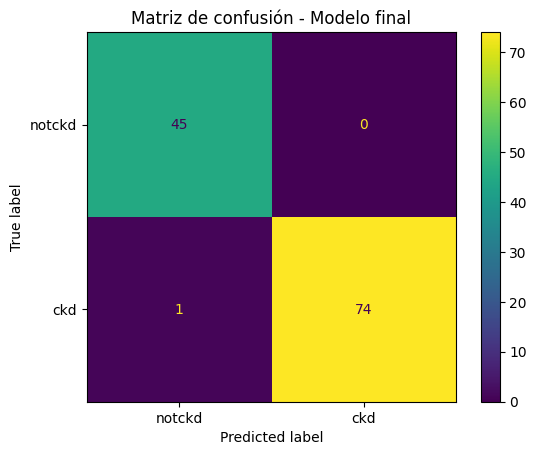

In [79]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["notckd", "ckd"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo final")
plt.show()

In [80]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["notckd", "ckd"]
))

              precision    recall  f1-score   support

      notckd       0.98      1.00      0.99        45
         ckd       1.00      0.99      0.99        75

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



### Evaluación final del modelo en el conjunto de prueba

El modelo seleccionado fue evaluado sobre el conjunto de prueba, el cual no fue utilizado durante el entrenamiento ni durante la validación cruzada.

Los resultados obtenidos fueron: Accuracy de 0.9917, Precision de 1.0000, Recall de 0.9867, F1-Score de 0.9933 y AUC de 0.9997. Estos valores indican un desempeño alto del modelo en datos no vistos.

La matriz de confusión muestra que el modelo clasificó correctamente 45 pacientes sin enfermedad renal crónica (`notckd`) y 74 pacientes con enfermedad renal crónica (`ckd`). No se presentaron falsos positivos, es decir, ningún paciente sano fue clasificado erróneamente como enfermo.

Sin embargo, se presentó un falso negativo: un paciente con enfermedad renal crónica fue clasificado como `notckd`. Este tipo de error es especialmente importante en este problema, ya que podría implicar que un paciente enfermo no reciba seguimiento, diagnóstico o tratamiento oportuno.

Aunque el desempeño general del modelo es alto, la interpretación de los errores muestra que el Recall sigue siendo una métrica clave, ya que permite evaluar la capacidad del modelo para detectar correctamente los casos positivos de enfermedad renal crónica.


In [88]:
# Comparación de falsos positivos y falsos negativos en test para varios modelos

modelos_test = {
    "Regresión Logística": pipeline_logistic,
    "Random Forest": pipeline_random_forest,
    "XGBoost": pipeline_xgboost,
    "Balanced Random Forest": pipeline_balanced_random_forest
}

resultados_errores_test = []

for nombre_modelo, modelo in modelos_test.items():
    
    # Entrenar modelo con el conjunto de entrenamiento
    modelo.fit(X_train, y_train)
    
    # Predecir en test
    y_pred_modelo = modelo.predict(X_test)
    
    # Matriz de confusión
    cm_modelo = confusion_matrix(y_test, y_pred_modelo)
    TN, FP, FN, TP = cm_modelo.ravel()
    
    resultados_errores_test.append({
        "Modelo": nombre_modelo,
        "Verdaderos negativos": TN,
        "Falsos positivos": FP,
        "Falsos negativos": FN,
        "Verdaderos positivos": TP,
        "Precision": round(precision_score(y_test, y_pred_modelo), 4),
        "Recall": round(recall_score(y_test, y_pred_modelo), 4),
        "F1-Score": round(f1_score(y_test, y_pred_modelo), 4)
    })

tabla_errores_test = pd.DataFrame(resultados_errores_test)

tabla_errores_test

,Modelo,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos,Precision,Recall,F1-Score
0,Regresión Logística,45,0,1,74,1.0,0.9867,0.9933
1,Random Forest,45,0,1,74,1.0,0.9867,0.9933
2,XGBoost,45,0,0,75,1.0,1.0000,1.0000
3,Balanced Random Forest,45,0,1,74,1.0,0.9867,0.9933


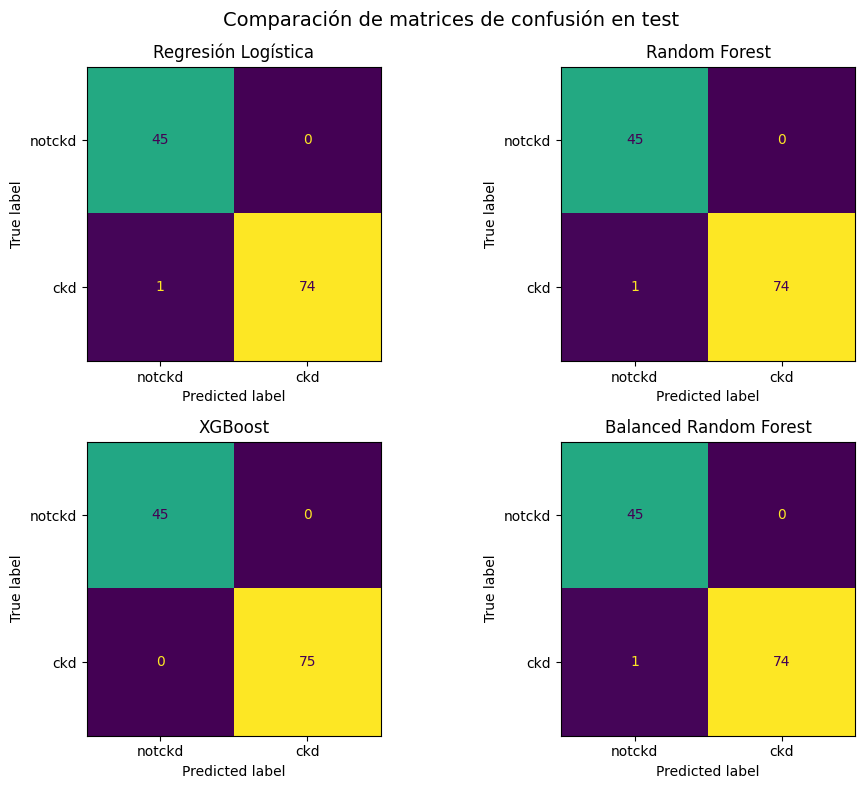

In [90]:
# Matrices de confusión comparativas por modelo

from sklearn.metrics import ConfusionMatrixDisplay

modelos_test = {
    "Regresión Logística": pipeline_logistic,
    "Random Forest": pipeline_random_forest,
    "XGBoost": pipeline_xgboost,
    "Balanced Random Forest": pipeline_balanced_random_forest
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (nombre_modelo, modelo) in zip(axes, modelos_test.items()):
    
    # Entrenar modelo
    modelo.fit(X_train, y_train)
    
    # Predecir en test
    y_pred_modelo = modelo.predict(X_test)
    
    # Matriz de confusión
    cm_modelo = confusion_matrix(y_test, y_pred_modelo)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_modelo,
        display_labels=["notckd", "ckd"]
    )
    
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(nombre_modelo)

plt.suptitle("Comparación de matrices de confusión en test", fontsize=14)
plt.tight_layout()
plt.show()

### Comparación de matrices de confusión entre modelos

Se compararon las matrices de confusión de varios modelos en el conjunto de prueba para analizar directamente los falsos positivos y falsos negativos.

La Regresión Logística, Random Forest y Balanced Random Forest presentaron el mismo comportamiento: clasificaron correctamente los 45 pacientes sin enfermedad renal crónica y 74 de los 75 pacientes con enfermedad, dejando un falso negativo.

XGBoost fue el único modelo que no presentó errores en el conjunto de prueba, ya que clasificó correctamente los 45 pacientes `notckd` y los 75 pacientes `ckd`.

Este resultado muestra que XGBoost es una alternativa fuerte si el objetivo principal es reducir completamente los falsos negativos. Sin embargo, la selección final del modelo también debe considerar la validación cruzada, la estabilidad, la interpretabilidad y la facilidad para explicar los resultados.

### Análisis gráfico de aciertos y errores de clasificación

Además de la matriz de confusión tradicional, se construye una visualización de los tipos de clasificación del modelo: verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Esta visualización permite identificar de manera más clara cuántos errores cometió el modelo y qué tipo de error fue más relevante en el conjunto de prueba.

In [81]:
# Análisis de aciertos y errores de clasificación

# Obtener valores de la matriz de confusión
TN, FP, FN, TP = cm.ravel()

# Crear tabla resumen
errores_modelo = pd.DataFrame({
    "Tipo": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "Cantidad": [
        TN,
        FP,
        FN,
        TP
    ]
})

errores_modelo

,Tipo,Cantidad
0,Verdaderos negativos,45
1,Falsos positivos,0
2,Falsos negativos,1
3,Verdaderos positivos,74


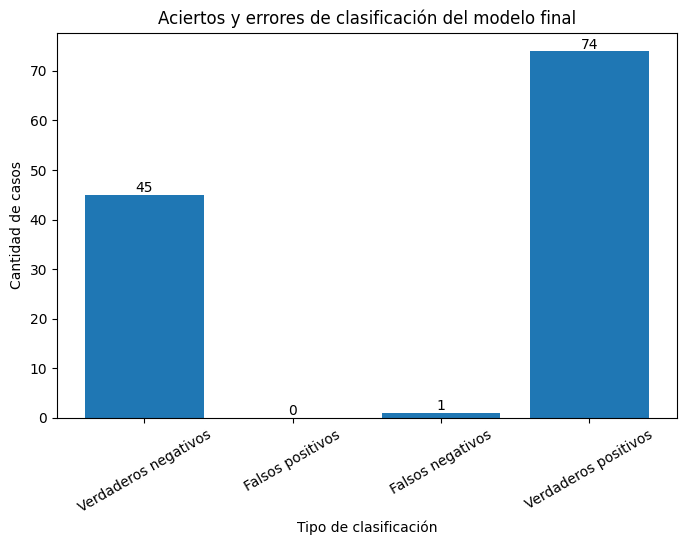

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    errores_modelo["Tipo"],
    errores_modelo["Cantidad"]
)

plt.title("Aciertos y errores de clasificación del modelo final")
plt.xlabel("Tipo de clasificación")
plt.ylabel("Cantidad de casos")
plt.xticks(rotation=30)

# Mostrar cantidades encima de cada barra
for i, valor in enumerate(errores_modelo["Cantidad"]):
    plt.text(i, valor + 0.5, str(valor), ha="center")

plt.show()

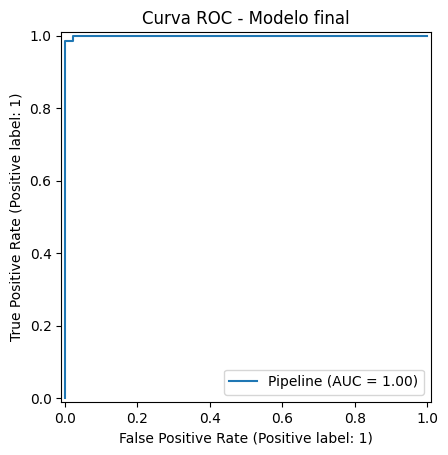

In [83]:
from sklearn.metrics import RocCurveDisplay

# Curva ROC del modelo final
RocCurveDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test
)

plt.title("Curva ROC - Modelo final")
plt.show()

### Curva ROC del modelo final

La curva ROC del modelo final muestra una alta capacidad discriminativa para separar las clases `ckd` y `notckd`.

El AUC obtenido en el conjunto de prueba fue de 0.9997, lo que indica que el modelo tiene una capacidad muy alta para distinguir entre pacientes con enfermedad renal crónica y pacientes sin enfermedad renal crónica.

La curva se ubica muy cerca de la esquina superior izquierda, lo cual refleja una alta sensibilidad y una baja tasa de falsos positivos. Sin embargo, este resultado debe interpretarse junto con la matriz de confusión, donde se observó un falso negativo.

En este contexto, la sensibilidad o Recall es especialmente importante, ya que permite evaluar qué tan bien el modelo identifica a los pacientes que realmente presentan enfermedad renal crónica.

## 9. Interpretación de variables del modelo final

Como el modelo final seleccionado corresponde a una Regresión Logística, la interpretación de variables se realiza a partir de los coeficientes del modelo.

Los coeficientes permiten identificar qué variables tienen mayor influencia en la clasificación. Coeficientes positivos aumentan la probabilidad de clasificar un paciente como `ckd`, mientras que coeficientes negativos disminuyen dicha probabilidad.

In [84]:
# Extraer nombres de variables después del preprocesamiento
preprocessor_final = modelo_final.named_steps["preprocessor"]
modelo_logistico = modelo_final.named_steps["model"]

try:
    feature_names = preprocessor_final.get_feature_names_out()
except:
    ohe = preprocessor_final.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(columnas_categoricas)
    feature_names = np.concatenate([columnas_numericas, cat_features])

# Extraer coeficientes del modelo logístico
coeficientes = modelo_logistico.coef_[0]

# Crear tabla de coeficientes
tabla_coeficientes = pd.DataFrame({
    "variable": feature_names,
    "coeficiente": coeficientes,
    "valor_absoluto": np.abs(coeficientes)
})

# Ordenar por importancia absoluta
tabla_coeficientes = tabla_coeficientes.sort_values(
    by="valor_absoluto",
    ascending=False
)

tabla_coeficientes.head(15)

,variable,coeficiente,valor_absoluto
2,num__sg,-1.650913,1.650913
10,num__hemo,-1.564089,1.564089
3,num__al,1.176524,1.176524
29,cat__appet_poor,1.126760,1.126760
28,cat__appet_good,-1.125723,1.125723
11,num__pcv,-1.053589,1.053589
7,num__sc,0.922858,0.922858
23,cat__htn_yes,0.820279,0.820279
22,cat__htn_no,-0.819241,0.819241
25,cat__dm_yes,0.728276,0.728276


### Interpretación de coeficientes del modelo final

Como el modelo final seleccionado corresponde a una Regresión Logística, la interpretación de las variables se realiza a partir de sus coeficientes.

Dado que la clase `ckd` fue codificada como 1 y la clase `notckd` como 0, los coeficientes positivos aumentan la probabilidad de que un paciente sea clasificado como `ckd`, mientras que los coeficientes negativos disminuyen dicha probabilidad.

Las variables con mayor influencia en el modelo fueron `sg`, `hemo`, `al`, `appet`, `pcv`, `sc`, `htn`, `dm`, `su`, `bp`, `rbcc` y `sod`.

Se observa que variables como `al`, `sc`, `htn_yes`, `dm_yes`, `su` y `bp` tienen coeficientes positivos, lo que indica que valores altos o presencia de estas condiciones aumentan la probabilidad de clasificar un paciente como `ckd`.

Por otro lado, variables como `sg`, `hemo`, `pcv`, `rbcc` y `sod` tienen coeficientes negativos, lo que indica que valores más altos en estas variables disminuyen la probabilidad de clasificar un paciente como `ckd`.

En las variables categóricas codificadas mediante `OneHotEncoder`, se observa que categorías como `appet_poor`, `htn_yes` y `dm_yes` aumentan la probabilidad de enfermedad renal crónica, mientras que categorías como `appet_good`, `htn_no` y `dm_no` se asocian con menor probabilidad de pertenecer a la clase `ckd`.

Estos resultados son coherentes con el contexto del problema, ya que variables clínicas como hemoglobina, creatinina sérica, albúmina, hipertensión, diabetes y apetito pueden estar relacionadas con la presencia de enfermedad renal crónica.


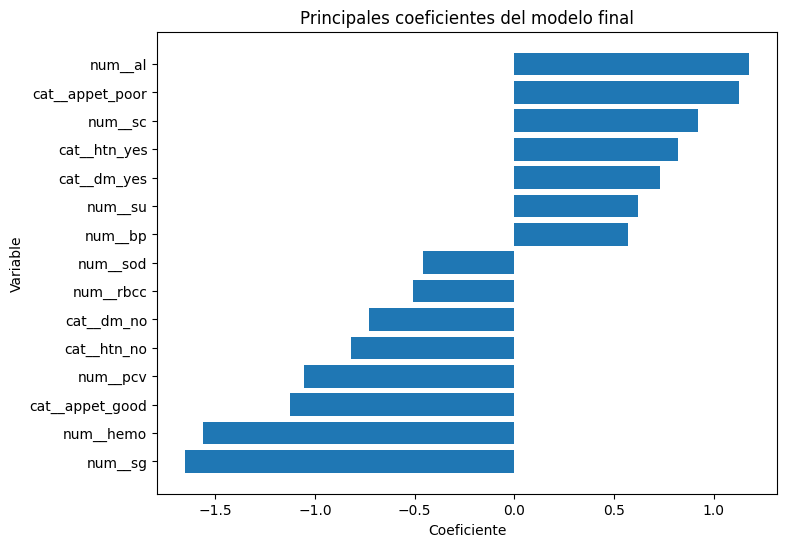

In [85]:
# Gráfico de los 15 coeficientes más importantes
top_coeficientes = tabla_coeficientes.head(15).sort_values("coeficiente")

plt.figure(figsize=(8, 6))
plt.barh(top_coeficientes["variable"], top_coeficientes["coeficiente"])
plt.title("Principales coeficientes del modelo final")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

## 10. Selección del modelo final

El modelo final seleccionado fue la Regresión Logística base.

Esta selección no se realizó únicamente con base en Accuracy. Se consideraron varios criterios: desempeño en validación cruzada, resultados en el conjunto de prueba, interpretabilidad y tipo de error más crítico para el problema.

En validación cruzada, la Regresión Logística base presentó un desempeño alto y equilibrado, con Accuracy de 0.9929, Precision de 1.0000, Recall de 0.9886, F1-Score de 0.9942 y AUC de 0.9989.

También se evaluó Balanced Random Forest como una alternativa de ensamble basada en árboles orientada al manejo del desbalance. Este modelo obtuvo un desempeño muy alto, con Accuracy de 0.9929, Precision de 1.0000, Recall de 0.9886, F1-Score de 0.9941 y AUC de 1.0000.

Sin embargo, al realizar el ajuste de hiperparámetros, ni la Regresión Logística ajustada ni Balanced Random Forest ajustado mejoraron frente a sus versiones base. La Regresión Logística ajustada alcanzó un Recall de 1.0000, pero perdió mucho desempeño en Precision, Accuracy y F1-Score. Balanced Random Forest ajustado también redujo ligeramente algunas métricas frente a su versión base.

En el conjunto de prueba, la Regresión Logística base mantuvo un desempeño alto, con Accuracy de 0.9917, Precision de 1.0000, Recall de 0.9867, F1-Score de 0.9933 y AUC de 0.9997.

Aunque Balanced Random Forest fue útil para considerar el desbalance de clases, la Regresión Logística base se selecciona como modelo final porque ofrece un desempeño muy alto, buen equilibrio entre métricas y mayor interpretabilidad. Al ser un modelo lineal, permite analizar directamente los coeficientes y entender qué variables aumentan o disminuyen la probabilidad de clasificar un paciente como `ckd`.

En este problema, el error más crítico es el falso negativo, es decir, clasificar como sano a un paciente que realmente presenta enfermedad renal crónica. El modelo final presentó solo un falso negativo en el conjunto de prueba, manteniendo un Recall alto y un buen equilibrio general entre las métricas.

Por estas razones, se selecciona la Regresión Logística base como modelo final.

## 11. Guardado del modelo

Finalmente, se guarda el modelo final seleccionado y la información de las variables utilizadas.

El modelo se guarda en la carpeta `models/` con el nombre `model_classification.joblib`, mientras que la información de las variables predictoras se guarda como `features_classification.joblib`.

Esto permite reutilizar el modelo posteriormente sin necesidad de volver a entrenarlo.

In [86]:
import joblib
from pathlib import Path

# Crear carpeta models si no existe
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Guardar modelo final
joblib.dump(
    modelo_final,
    models_dir / "model_classification.joblib"
)

# Guardar información de variables
features_info = {
    "features": X.columns.tolist(),
    "target": target,
    "target_mapping": {
        "notckd": 0,
        "ckd": 1
    },
    "numeric_features": columnas_numericas,
    "categorical_features": columnas_categoricas
}

joblib.dump(
    features_info,
    models_dir / "features_classification.joblib"
)

print("Modelo guardado en:", models_dir / "model_classification.joblib")
print("Variables guardadas en:", models_dir / "features_classification.joblib")

Modelo guardado en: ..\models\model_classification.joblib
Variables guardadas en: ..\models\features_classification.joblib


In [87]:
list(models_dir.iterdir())

[WindowsPath('../models/features_classification.joblib'),
 WindowsPath('../models/features_regression.joblib'),
 WindowsPath('../models/linear_regression.joblib'),
 WindowsPath('../models/model_classification.joblib'),
 WindowsPath('../models/model_regression.joblib'),
 WindowsPath('../models/random_forest.pkl'),
 WindowsPath('../models/scaler.joblib'),
 WindowsPath('../models/xgboost_model.json')]

## 12. Análisis complementario: Regresión Logística vs XGBoost

En esta sección se compara el modelo final seleccionado, Regresión Logística base, con XGBoost base.

Este análisis complementario busca revisar si XGBoost mejora el comportamiento frente al error más crítico del problema: el falso negativo, es decir, clasificar como sano a un paciente que realmente presenta enfermedad renal crónica.

In [91]:
# Comparación directa en test: Regresión Logística base vs XGBoost base

modelos_comparacion = {
    "Regresión Logística base": pipeline_logistic,
    "XGBoost base": pipeline_xgboost
}

resultados_comparacion = []
matrices_comparacion = {}

for nombre_modelo, modelo in modelos_comparacion.items():
    
    # Entrenar con el conjunto de entrenamiento
    modelo.fit(X_train, y_train)
    
    # Predicciones en test
    y_pred_modelo = modelo.predict(X_test)
    y_pred_proba_modelo = modelo.predict_proba(X_test)[:, 1]
    
    # Matriz de confusión
    cm_modelo = confusion_matrix(y_test, y_pred_modelo)
    TN, FP, FN, TP = cm_modelo.ravel()
    
    matrices_comparacion[nombre_modelo] = cm_modelo
    
    resultados_comparacion.append({
        "Modelo": nombre_modelo,
        "Accuracy": round(accuracy_score(y_test, y_pred_modelo), 4),
        "Precision": round(precision_score(y_test, y_pred_modelo), 4),
        "Recall": round(recall_score(y_test, y_pred_modelo), 4),
        "F1-Score": round(f1_score(y_test, y_pred_modelo), 4),
        "AUC": round(roc_auc_score(y_test, y_pred_proba_modelo), 4),
        "Verdaderos negativos": TN,
        "Falsos positivos": FP,
        "Falsos negativos": FN,
        "Verdaderos positivos": TP
    })

tabla_logistica_vs_xgboost = pd.DataFrame(resultados_comparacion)

tabla_logistica_vs_xgboost

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos
0,Regresión Logística base,0.9917,1.0,0.9867,0.9933,0.9997,45,0,1,74
1,XGBoost base,1.0000,1.0,1.0000,1.0000,1.0000,45,0,0,75


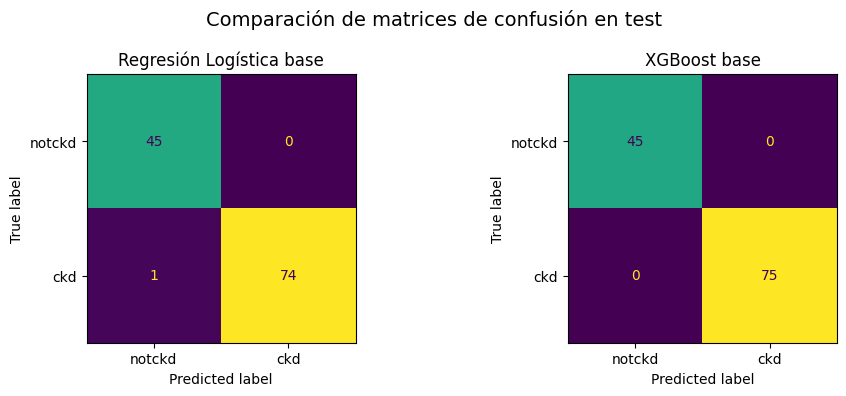

In [92]:
# Matrices de confusión comparativas: Regresión Logística vs XGBoost

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (nombre_modelo, cm_modelo) in zip(axes, matrices_comparacion.items()):
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_modelo,
        display_labels=["notckd", "ckd"]
    )
    
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(nombre_modelo)

plt.suptitle("Comparación de matrices de confusión en test", fontsize=14)
plt.tight_layout()
plt.show()

### Comparación complementaria entre Regresión Logística y XGBoost

La comparación entre Regresión Logística y XGBoost permite analizar si otro modelo reduce el error más crítico del problema: el falso negativo.

En el conjunto de prueba, XGBoost obtuvo 0 falsos positivos y 0 falsos negativos, mientras que la Regresión Logística obtuvo 0 falsos positivos y 1 falso negativo. Esto indica que XGBoost logró detectar correctamente todos los pacientes con enfermedad renal crónica en el conjunto de prueba.

Sin embargo, la selección de un modelo no debe basarse únicamente en la reducción del falso negativo. También se deben considerar métricas como Precision, Recall, F1-Score, AUC, desempeño en validación cruzada, estabilidad e interpretabilidad.

En este caso, XGBoost mostró el mejor comportamiento en test, pero la Regresión Logística presentó un desempeño muy alto en validación cruzada y ofrece mayor interpretabilidad mediante el análisis de coeficientes.

Por tanto, XGBoost puede considerarse una alternativa fuerte si el objetivo principal es minimizar falsos negativos, mientras que la Regresión Logística se mantiene como una opción defendible cuando se prioriza el equilibrio entre desempeño e interpretabilidad.